In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt

# 2 Generating a Simple Signal

We begin with a signal composed of two sine waves at 5 Hz and 20 Hz.

In [ ]:
Fs = 200 # Sampling frequency (Sample per second)
T = 1/ Fs
t = np . arange (0 , 1 , T ) # Sample interval
f1 , f2 = 5 , 20
signal = np . sin (2* np . pi * f1 * t ) + 0.5* np . sin (2* np . pi * f2 * t )
plt . plot (t , signal )
plt . title ( " Time - domain Signal " )
plt . xlabel ( " Time ( s ) " )
plt . ylabel ( " Amplitude " )
plt . grid ( True )
plt . show ()

# 3 Applying the FFT

The FFT transforms the signal into the frequency domain.

In [ ]:
n = len ( signal )
fft_result = np . fft . fft ( signal )
fft_freq = np . fft . fftfreq (n , T )
mask = fft_freq >= 0
fft_result = np . abs ( fft_result [ mask ]) * (2/ n )
fft_freq = fft_freq [ mask ]
plt . stem ( fft_freq , fft_result , basefmt = " " )
plt . title ( " Frequency Spectrum " )
plt . xlabel ( " Frequency ( Hz ) " )
plt . ylabel ( " Magnitude " )
plt . grid ( True )
plt . show ()

# Exercice 1

Task: Add a sine wave at 50 Hz with amplitude 0.3. Expected result: The frequency
spectrum should now show three peaks at 5 Hz, 20 Hz, and 50 Hz.

In [ ]:
Fs = 200
T = 1/Fs
t = np . arange (0 , 1 , T ) # Sample interval
f1 , f2, f3 = 5 , 20, 50
signal = np . sin (2* np . pi * f1 * t ) + 0.5* np . sin (2* np . pi * f2 * t ) + 0.3* np . sin (2* np . pi * f3 * t )
plt . plot (t , signal )
plt . title ( " Time - domain Signal " )
plt . xlabel ( " Time ( s ) " )
plt . ylabel ( " Amplitude " )
plt . grid ( True )
plt . show ()

In [ ]:
n = len ( signal )
fft_result = np . fft . fft ( signal )
fft_freq = np . fft . fftfreq (n , T )
mask = fft_freq >= 0
fft_result = np . abs ( fft_result [ mask ]) * (2/ n )
fft_freq = fft_freq [ mask ]
plt . stem ( fft_freq , fft_result , basefmt = " " )
plt . title ( " Frequency Spectrum " )
plt . xlabel ( " Frequency ( Hz ) " )
plt . ylabel ( " Magnitude " )
plt . grid ( True )
plt . show ()

# 4 Noise and the FFT

Real-world signals often contain noise.

In [ ]:
# Add noise
noisy_signal = signal + 0.5* np . random . randn ( len ( t ) )
fft_noisy = np . fft . fft ( noisy_signal )
fft_noisy = np . abs ( fft_noisy [ mask ]) * (2/ n )
plt . stem ( fft_freq , fft_noisy , basefmt = " " )
plt . title ( " Noisy Frequency Spectrum " )
plt . xlabel ( " Frequency ( Hz ) " )
plt . ylabel ( " Magnitude " )
plt . grid ( True )
plt . show ()

# Exercise 2

Task: Try different noise strengths (0.2, 0.5, 1.0). Expected result: Peaks at 5 Hz and
20 Hz become harder to distinguish under heavy noise, but they are still visible.

In [ ]:
# Add noise with amp=0.2
noisy_signal = signal + 0.2* np . random . randn ( len ( t ) )
fft_noisy = np . fft . fft ( noisy_signal )
fft_noisy = np . abs ( fft_noisy [ mask ]) * (2/ n )
plt . stem ( fft_freq , fft_noisy , basefmt = " " )
plt . title ( " Noisy Frequency Spectrum with amp=0.2 " )
plt . xlabel ( " Frequency ( Hz ) " )
plt . ylabel ( " Magnitude " )
plt . grid ( True )
plt . show ()

In [ ]:
# Add noise with amp=0.5
noisy_signal = signal + 0.5* np . random . randn ( len ( t ) )
fft_noisy = np . fft . fft ( noisy_signal )
fft_noisy = np . abs ( fft_noisy [ mask ]) * (2/ n )
plt . stem ( fft_freq , fft_noisy , basefmt = " " )
plt . title ( " Noisy Frequency Spectrum with amp=0.5" )
plt . xlabel ( " Frequency ( Hz ) " )
plt . ylabel ( " Magnitude " )
plt . grid ( True )
plt . show ()

In [ ]:
# Add noise with amp=1.0
noisy_signal = signal + 1* np . random . randn ( len ( t ) )
fft_noisy = np . fft . fft ( noisy_signal )
fft_noisy = np . abs ( fft_noisy [ mask ]) * (2/ n )
plt . stem ( fft_freq , fft_noisy , basefmt = " " )
plt . title ( " Noisy Frequency Spectrum with amp = 1.0" )
plt . xlabel ( " Frequency ( Hz ) " )
plt . ylabel ( " Magnitude " )
plt . grid ( True )
plt . show ()

# 5 Filtering

We can filter out high-frequency noise by removing FFT components above 30 Hz.

In [ ]:
fft_noisy = np . fft . fft ( noisy_signal )
freqs = np . fft . fftfreq (n , T )
cutoff = 30
mask = np . abs ( freqs ) <= cutoff
fft_filtered = fft_noisy * mask
reconstructed = np . fft . ifft ( fft_filtered ) . real
plt . plot (t , noisy_signal , label = " Noisy " )
plt . plot (t , reconstructed , label = " Filtered " )
plt . legend ()
plt . title ( " Signal Filtering with FFT " )
plt . show ()

# Exercise 3

Task: Reconstruct the signal using inverse FFT after filtering out frequencies above 30
Hz. Expected result: The reconstructed signal should closely resemble the original
clean signal.

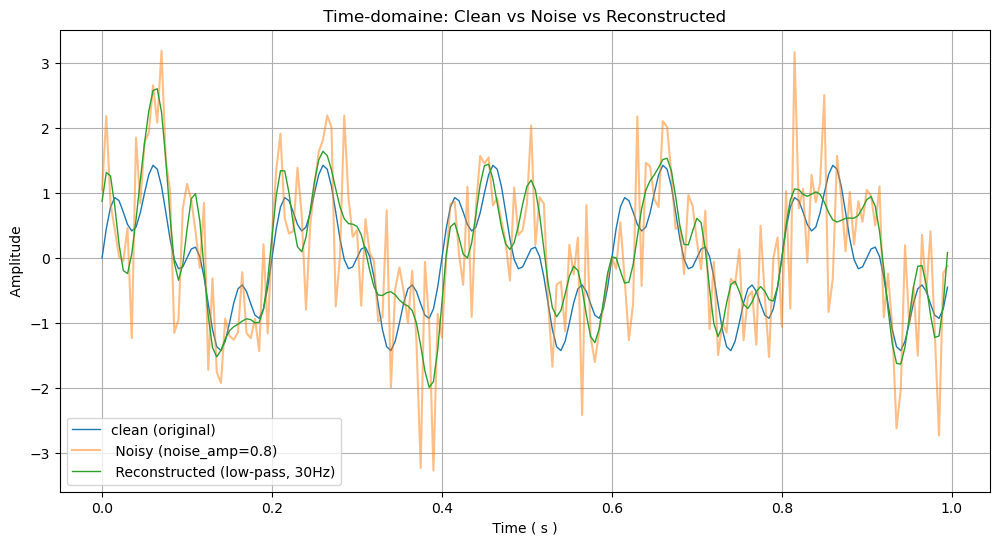

/tmp/ipykernel_14208/4221894163.py:38: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt . stem (freqs[pos_mask] , mag_noise[pos_mask] , basefmt="", label = "Noise Spectrum", use_line_collection=True)
/tmp/ipykernel_14208/4221894163.py:39: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt . stem (freqs[pos_mask] , mag_filtered[pos_mask] , basefmt="", linefmt='C1-', markerfmt='C1o', label = "Filtered Spectrum", use_line_collection=True)


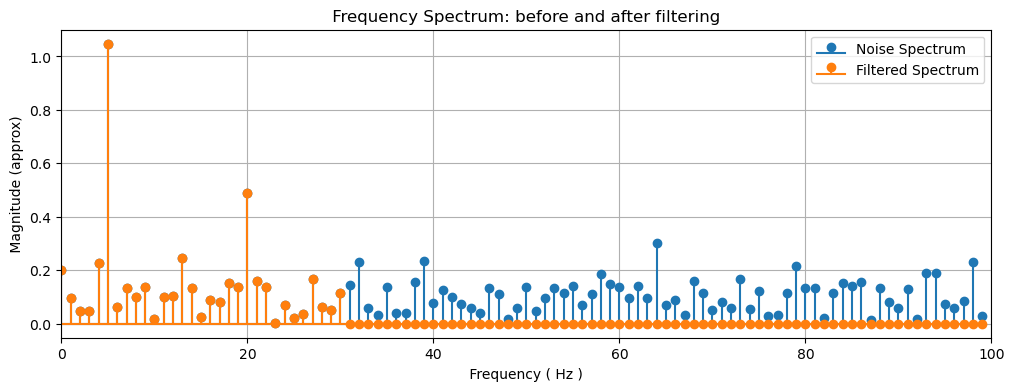

MSE (clean vs noisy): 0.7981
MSE (clean vs reconstructed): 0.2741


In [4]:
Fs = 200
T = 1/Fs
t = np . arange (0 , 1 , T ) # Sample interval
n = len(t)

f1 , f2 = 5 , 20
clean = np . sin (2* np . pi * f1 * t ) + 0.5* np . sin (2* np . pi * f2 * t )

noise_amp = 0.8
noisy = clean + noise_amp * np.random.randn(n)

fft_noisy = np.fft.fft(noisy)
freqs = np.fft.fftfreq(n, T)

cutoff = 30
filter_mask = np . abs ( freqs ) <= cutoff
fft_filtered = fft_noisy * filter_mask

reconstructed = np . fft . ifft ( fft_filtered ) . real

plt.figure(figsize=(12,6))
plt . plot (t , clean , label = "clean (original)", linewidth=1)
plt . plot (t , noisy , label = f" Noisy (noise_amp={noise_amp})", alpha=0.5 )
plt . plot (t , reconstructed , label = " Reconstructed (low-pass, 30Hz)", linewidth=1 )
plt . xlabel ( " Time ( s ) " )
plt . ylabel ( " Amplitude " )
plt . title ( " Time-domaine: Clean vs Noise vs Reconstructed " )
plt . legend ()
plt.grid(True)
plt . show ()

mag_noise = np . abs ( fft_noisy ) * (2/ n )
mag_filtered = np . abs ( fft_filtered ) * (2/ n )

pos_mask = freqs >= 0

plt.figure(figsize=(12,4))
plt . stem (freqs[pos_mask] , mag_noise[pos_mask] , basefmt="", label = "Noise Spectrum", use_line_collection=True)
plt . stem (freqs[pos_mask] , mag_filtered[pos_mask] , basefmt="", linefmt='C1-', markerfmt='C1o', label = "Filtered Spectrum", use_line_collection=True)
plt.  xlim(0,100)
plt . xlabel ( " Frequency ( Hz ) " )
plt . ylabel ( " Magnitude (approx) " )
plt . title ( " Frequency Spectrum: before and after filtering " )
plt . legend ()
plt.grid(True)
plt . show ()


mse_noisy = np . mean (( clean - noisy ) ** 2 )
mse_recon = np . mean (( clean - reconstructed ) ** 2 )
print(f"MSE (clean vs noisy): {mse_noisy:.4f}")
print(f"MSE (clean vs reconstructed): {mse_recon:.4f}")

5.1 Observation

Filtering removes high-frequency noise but may introduce small artifacts (ringing). This
is common with ideal FFT filters.

6 Summary

• The FFT converts signals from time domain to frequency domain.

• Peaks in the spectrum reveal which frequencies are present.

• Noise spreads across the frequency spectrum.

• Filtering in the frequency domain can recover useful signals.

# 7 Radio Astronomy Example

Radio telescopes detect extremely weak signals from space, often buried under thermal
noise. One classic task is to identify narrow-band emission lines (e.g., the neutral hydro-
gen line at 1420 MHz) or periodic pulsar signals.

# 7.1 Simulated Observation

We simulate an observation where:
• The sampling frequency is 1000 Hz (simplified).
• The telescope is observing for 1 second.
• A weak sinusoidal signal at 60 Hz represents the astronomical source.
• Gaussian noise represents the receiver and sky noise.

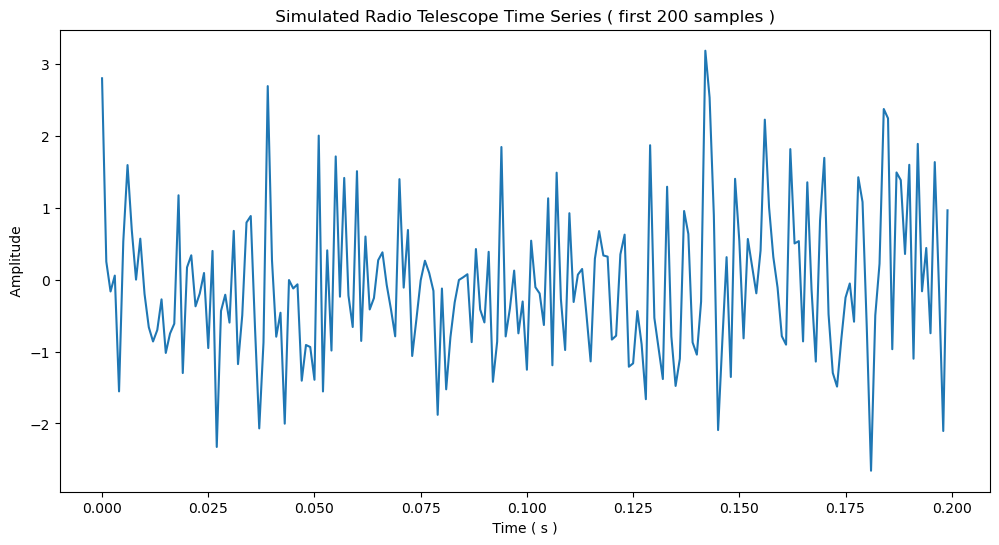

In [11]:
Fs = 1000 # sampling frequency ( Hz )
T = 1/ Fs
t = np . arange (0 , 1 , T )
n = len ( t )
# Simulated astronomical signal : weak sinusoid at 60 Hz
astro_freq = 60
astro_amp = 0.05 # very weak amplitude
astro_signal = astro_amp * np . sin (2* np . pi * astro_freq * t )
# Strong Gaussian noise
noise = np . random . randn ( n )
# Total observed signal
observed = astro_signal + noise
plt.figure(figsize=(12,6))
plt . plot ( t [:200] , observed [:200])
plt . title ( " Simulated Radio Telescope Time Series ( first 200 samples ) " )
plt . xlabel ( " Time ( s ) " )
plt . ylabel ( " Amplitude " )
plt . show ()

# 7.2 Frequency Analysis with FFT

In the time series the signal is invisible. The FFT can reveal the hidden tone.

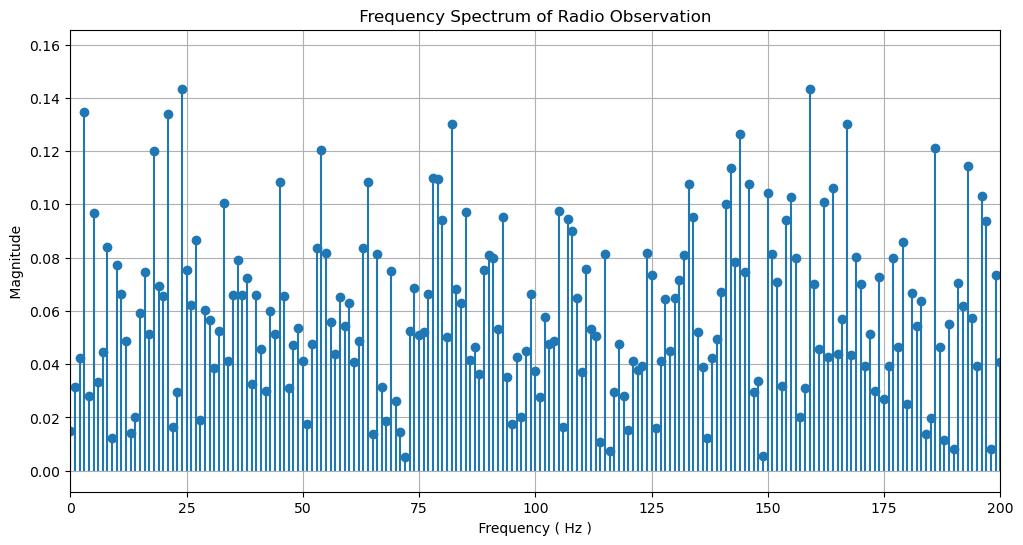

In [12]:
fft_result = np . fft . fft ( observed )
freqs = np . fft . fftfreq (n , T )
mask = freqs >= 0
fft_mag = np . abs ( fft_result [ mask ]) * (2/ n )
fft_freqs = freqs [ mask ]

plt.figure(figsize=(12,6))
plt . stem ( fft_freqs , fft_mag , basefmt = " " )
plt . xlim (0 , 200) # zoom into first 200 Hz
plt . title ( " Frequency Spectrum of Radio Observation " )
plt . xlabel ( " Frequency ( Hz ) " )
plt . ylabel ( " Magnitude " )
plt . grid ( True )
plt . show ()

7.3 Observation

Although the signal amplitude is only 0.05 compared to unit-variance noise, a clear spec-
tral peak emerges at 60 Hz. This is how astronomers detect hidden periodicities and
spectral lines in noisy data.

# Exercise 4

1. Try reducing the amplitude to 0.02 or 0.01. How low can the signal be before you
can no longer see it?

2. Increase the integration time (observe for 2 seconds instead of 1). How does this
affect your ability to detect the peak?

3. Replace the sinusoid with two nearby tones (e.g., 60 Hz and 65 Hz). Can you resolve
them both?

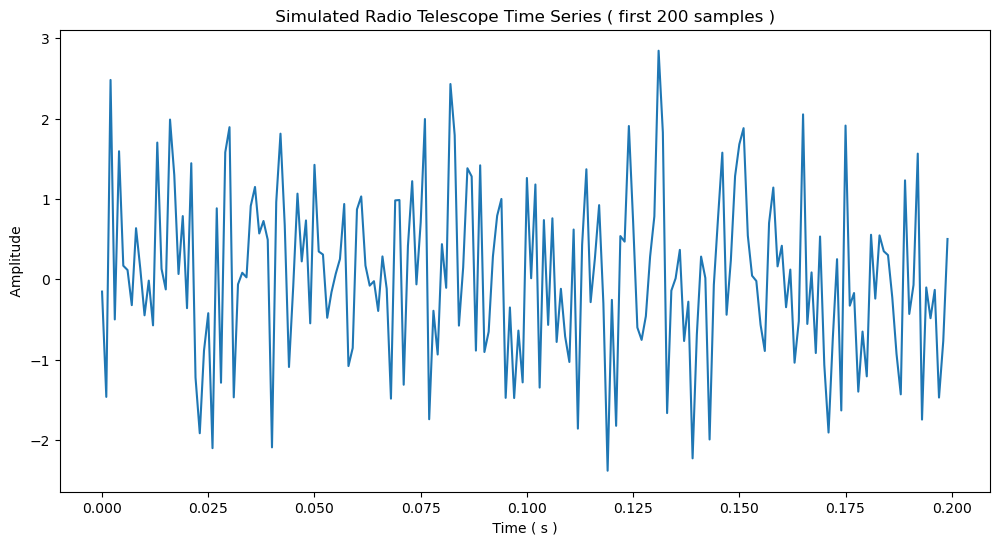

In [25]:
Fs = 1000 # sampling frequency ( Hz )
T = 1/ Fs
duration = 2.0
t = np . arange (0 , duration , T )
n = len ( t )
# Simulated astronomical signal : weak sinusoid at 60 Hz
astro_freq1 = 60
astro_freq2 = 65
astro_amp = 0.01 # very weak amplitude
astro_signal = astro_amp * np . sin (2* np . pi * astro_freq1 * t )
if astro_freq2 is not None:
    astro_signal += astro_amp * np . sin (2* np . pi * astro_freq2 * t )
    # Strong Gaussian noise
noise = np . random . randn ( n )
# Total observed signal
observed = astro_signal + noise
plt.figure(figsize=(12,6))
plt . plot ( t [:200] , observed [:200])
plt . title ( " Simulated Radio Telescope Time Series ( first 200 samples ) " )
plt . xlabel ( " Time ( s ) " )
plt . ylabel ( " Amplitude " )
plt . show ()

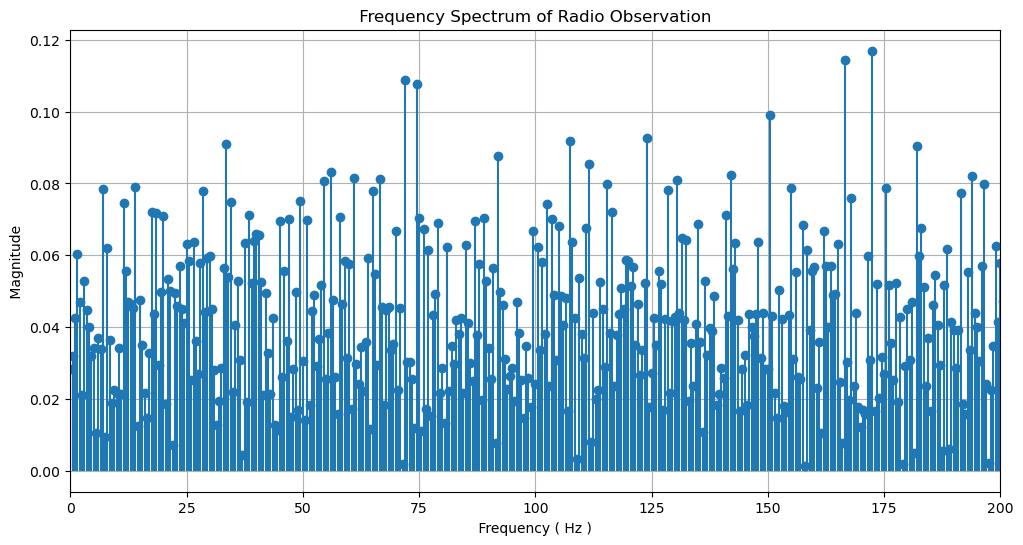

In [26]:
fft_result = np . fft . fft ( observed )
freqs = np . fft . fftfreq (n , T )
mask = freqs >= 0
fft_mag = np . abs ( fft_result [ mask ]) * (2/ n )
fft_freqs = freqs [ mask ]

plt.figure(figsize=(12,6))
plt . stem ( fft_freqs , fft_mag , basefmt = " " )
plt . xlim (0 , 200) # zoom into first 200 Hz
plt . title ( " Frequency Spectrum of Radio Observation " )
plt . xlabel ( " Frequency ( Hz ) " )
plt . ylabel ( " Magnitude " )
plt . grid ( True )
plt . show ()

7.4 Key Concept

Radio astronomy often relies on the fact that integrating longer (more samples)
reduces noise variance while the signal peak remains. This is why telescopes observe for
minutes or hours: the FFT spectrum gradually reveals hidden signals.